In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def getStuff(s,l=0,h=10):
    msg = s + "/" + s + "_accs"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", index_col=0)')

    df = pd.DataFrame(data=[eval('df' + str(i) + '.iloc[1]') for i in range(l,h)])
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [8]:
def getStuffTimes(s,l=0,h=10):
    msg = s + "/" + s + "_times"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", header=None)')
        #print(eval('df' + str(i)))

    df = pd.DataFrame(data=[eval('df' + str(i) + '[0]') for i in range(l,h)])
    df = df[df.columns[0:2]]
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [9]:
augmean, augstd, augmedian, augiqr = getStuff("aug",h=5)
vanmean, vanstd, vanmedian, vaniqr = getStuff("base",h=5)
symmean, symstd, symmedian, symiqr = getStuff("sym",h=5)
symaugmean, symaugstd, symaugmedian, symaugiqr = getStuff("symaug",h=5)

In [11]:
augmeant, augstdt, augmediant, augiqrt = getStuffTimes("aug",h=5)
vanmeant, vanstdt, vanmediant, vaniqrt = getStuffTimes("base",h=5)
symmeant, symstdt, symmediant, symiqrt = getStuffTimes("sym",h=5)
symaugmeant, symaugstdt, symaugmediant, symaugiqrt = getStuffTimes("symaug",h=5)

In [12]:
augmediant

0     99.980270
1    100.680335
dtype: float64

In [13]:
augiqrt

0    0.646825
1    0.134300
dtype: float64

In [14]:
symmediant

0    116.289808
1    365.151478
dtype: float64

In [15]:
symiqrt

0    0.262023
1    0.271424
dtype: float64

In [16]:
symaugmediant

0    100.137131
1    352.703780
dtype: float64

In [17]:
symaugiqrt

0    0.713036
1    0.171232
dtype: float64

In [18]:
vanmediant

0    118.347072
1    117.983462
dtype: float64

In [19]:
vaniqrt

0    0.835225
1    0.544256
dtype: float64

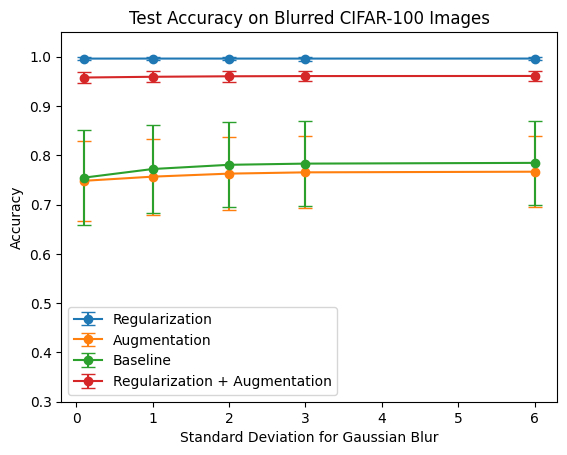

In [22]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmean, yerr=symstd, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmean, yerr=augstd, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmean, yerr=vanstd, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmean, yerr=symaugstd, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred CIFAR-100 Images')
plt.xlabel('Standard Deviation for Gaussian Blur')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0.3,1.05)
plt.savefig("CIFAR10_Blur.pdf")
plt.show()

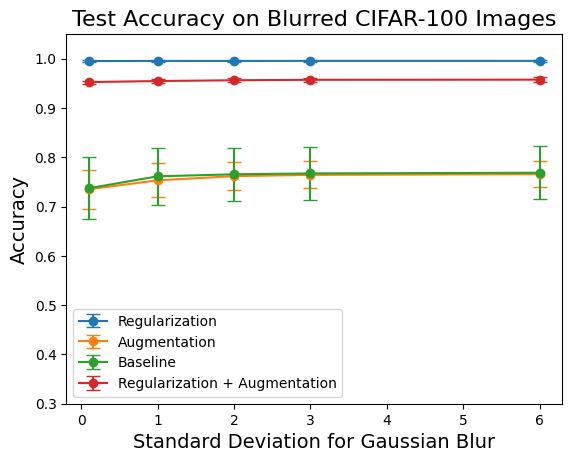

In [23]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmedian, yerr=symiqr, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmedian, yerr=augiqr, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmedian, yerr=vaniqr, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmedian, yerr=symaugiqr, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred CIFAR-100 Images', fontsize=16)
plt.xlabel('Standard Deviation for Gaussian Blur', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.ylim(0.3,1.05)
plt.savefig("CIFAR10_Blur-2.pdf")
plt.show()

In [24]:
augmean

0    0.74826
1    0.75672
2    0.76286
3    0.76546
4    0.76676
dtype: float64

In [25]:
augstd

0    0.080904
1    0.077278
2    0.074594
3    0.072943
4    0.071951
dtype: float64

In [26]:
symmean

0    0.99626
1    0.99634
2    0.99630
3    0.99630
4    0.99636
dtype: float64

In [27]:
symstd

0    0.003840
1    0.003788
2    0.003859
3    0.003890
4    0.003783
dtype: float64

In [28]:
vanmean

0    0.75466
1    0.77220
2    0.78076
3    0.78318
4    0.78468
dtype: float64

In [29]:
vanstd

0    0.096534
1    0.090075
2    0.086096
3    0.085484
4    0.084933
dtype: float64

In [30]:
augmedian

0    0.7352
1    0.7533
2    0.7618
3    0.7644
4    0.7658
dtype: float64

In [31]:
augiqr

0    0.03965
1    0.03450
2    0.02895
3    0.02730
4    0.02665
dtype: float64

In [32]:
symmedian

0    0.9953
1    0.9956
2    0.9956
3    0.9957
4    0.9957
dtype: float64

In [33]:
symiqr

0    0.00245
1    0.00245
2    0.00245
3    0.00245
4    0.00245
dtype: float64

In [34]:
vanmedian

0    0.7373
1    0.7614
2    0.7656
3    0.7673
4    0.7687
dtype: float64

In [35]:
vaniqr

0    0.06270
1    0.05720
2    0.05420
3    0.05365
4    0.05340
dtype: float64

In [36]:
symaugmedian

0    0.9527
1    0.9548
2    0.9564
3    0.9573
4    0.9576
dtype: float64

In [37]:
symaugiqr

0    0.00305
1    0.00380
2    0.00410
3    0.00425
4    0.00445
dtype: float64